<a href="https://colab.research.google.com/github/omora14/googCol/blob/main/owen_starter_signs_v2_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PREPARATION

In [ ]:
# Note: After you run this cell, the training and test data will be available in
# the file browser. (Click the folder icon on the left to view it)
#
# If you don't see the data after the cell completes, click the refresh button
# in the file browser (folder icon with circular arrow)

# First, let's download and unzip the data
!echo "Downloading files..."
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training1.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training2.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv

!echo "Unzipping files..."
!unzip -q /content/training1.zip
!unzip -q /content/training2.zip
!unzip -q /content/holdout.zip
!unzip -q /content/mini_holdout.zip

# Combine the two traning directories
!echo "Merging training data..."
!mkdir /content/training
!mv /content/training1/* /content/training
!mv /content/training2/* /content/training

# Cleanup
!echo "Cleaning up..."
!rmdir /content/training1
!rmdir /content/training2
!rm training1.zip
!rm training2.zip
!rm holdout.zip
!rm mini_holdout.zip

!echo "Data ready."

Unzipping files...
Merging training data...
Cleaning up...
Data ready.


In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# We're using keras' ImageDataGenerator class to load our image data.
# See (https://keras.io/api/preprocessing/image/#imagedatagenerator-class) for details
#
# A couple of things to note:
# 1. We're specifying a number for the seed, so we'll always get the same shuffle and split of our images.
# 2. Class names are inferred automatically from the image subdirectory names.
# 3. We're splitting the training data into 80% training, 20% validation.


training_dir = '/content/training/'
image_size = (100, 100)

# Split up the training data images into training and validations sets
# We'll use and ImageDataGenerator to do the splits
# ImageDataGenerator can also be used to do preprocessing and agumentation on the files as can be seen with rescale

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,       # rotate signs by up to 15 degrees
    width_shift_range=0.1,   # shift the image horizontally by 10%
    height_shift_range=0.1,  # shift the image vertically by 10%
    zoom_range=0.1,          # zoom in or out by 10%
    horizontal_flip=False,   # IMPORTANT
    # if you horizontally flip a turn right sign, it becomes a turn left sign. If you train the model on flipped signs, the self driving car will turn into oncoming traffic.
    validation_split=0.2
)
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size = image_size,
        subset="training",
        batch_size=32,
        class_mode='sparse',
        seed=42,shuffle=True)
validation_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=32,
        class_mode='sparse',
        subset="validation",
        seed=42)



Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [ ]:
#these might come in handy

target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
               'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
               'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
               'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
               'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
               'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
               'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
               'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
               'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']

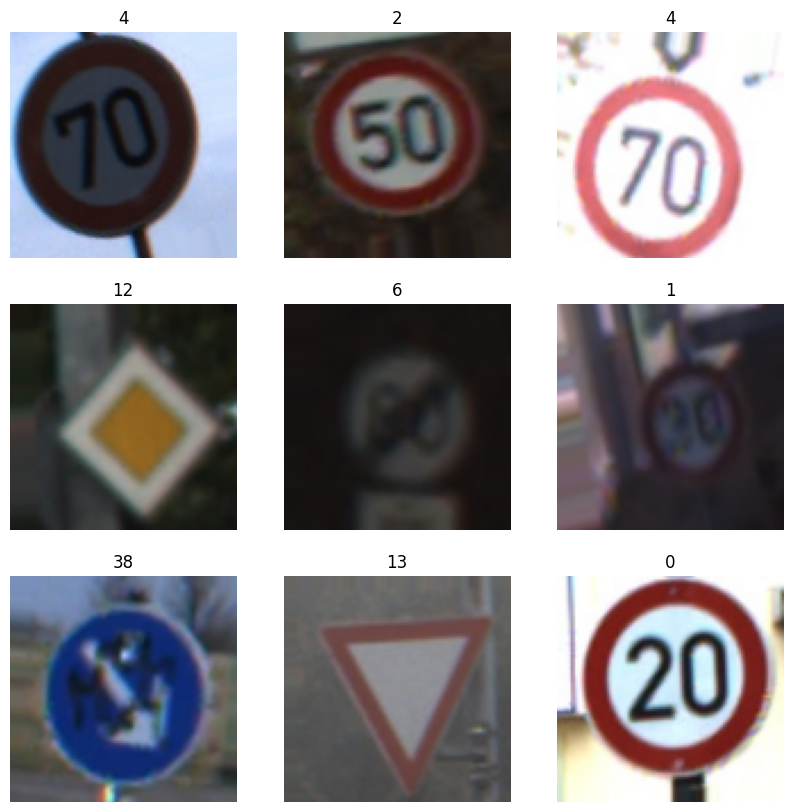

In [ ]:
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)
batch_size = images.shape[0]

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

# MODEL

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,       # rotate signs by up to 15 degrees
    width_shift_range=0.1,   # shift the image horizontally by 10%
    height_shift_range=0.1,  # shift the image vertically by 10%
    zoom_range=0.1,          # zoom in or out by 10%
    horizontal_flip=False,   # IMPORTANT: Keep this False!
    validation_split=0.2
)

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(43, activation='softmax')
])

## dark images were wrong, maybe we can add contrast

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.metrics import classification_report

answers_df = pd.read_csv('/content/mini_holdout_answers.csv')

true_labels = answers_df['ClassId'].values

unique_true_labels = np.unique(true_labels)

filtered_target_names = [target_names[i] for i in unique_true_labels]

print(classification_report(true_labels, predictions, labels=unique_true_labels, target_names=filtered_target_names))

NameError: name 'predictions' is not defined

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 127s 124ms/step - accuracy: 0.3957 - loss: 2.0411 - val_accuracy: 0.6162 - val_loss: 1.2092
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 110s 112ms/step - accuracy: 0.7046 - loss: 0.9150 - val_accuracy: 0.8037 - val_loss: 0.6662
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 109s 111ms/step - accuracy: 0.8247 - loss: 0.5413 - val_accuracy: 0.8091 - val_loss: 0.5986
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 116s 118ms/step - accuracy: 0.8727 - loss: 0.3897 - val_accuracy: 0.8778 - val_loss: 0.4306
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 109s 111ms/step - accuracy: 0.9045 - loss: 0.2954 - val_accuracy: 0.8978 - val_loss: 0.3775
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.9213 - loss: 0.2445 - val_accuracy: 0.9119 - val_loss: 0.3377
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.9319 - loss: 0.2117 - val_accuracy: 0.9119 - val_loss: 0.3665
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.9401 -

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

Found 201 images belonging to 1 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step


In [ ]:
from sklearn.metrics import classification_report

answers_df = pd.read_csv('/content/mini_holdout_answers.csv')

true_labels = answers_df['ClassId'].values

print(classification_report(true_labels, predictions, target_names=target_names))

ValueError: Number of classes, 38, does not match size of target_names, 43. Try specifying the labels parameter

#Kate's Graphs!

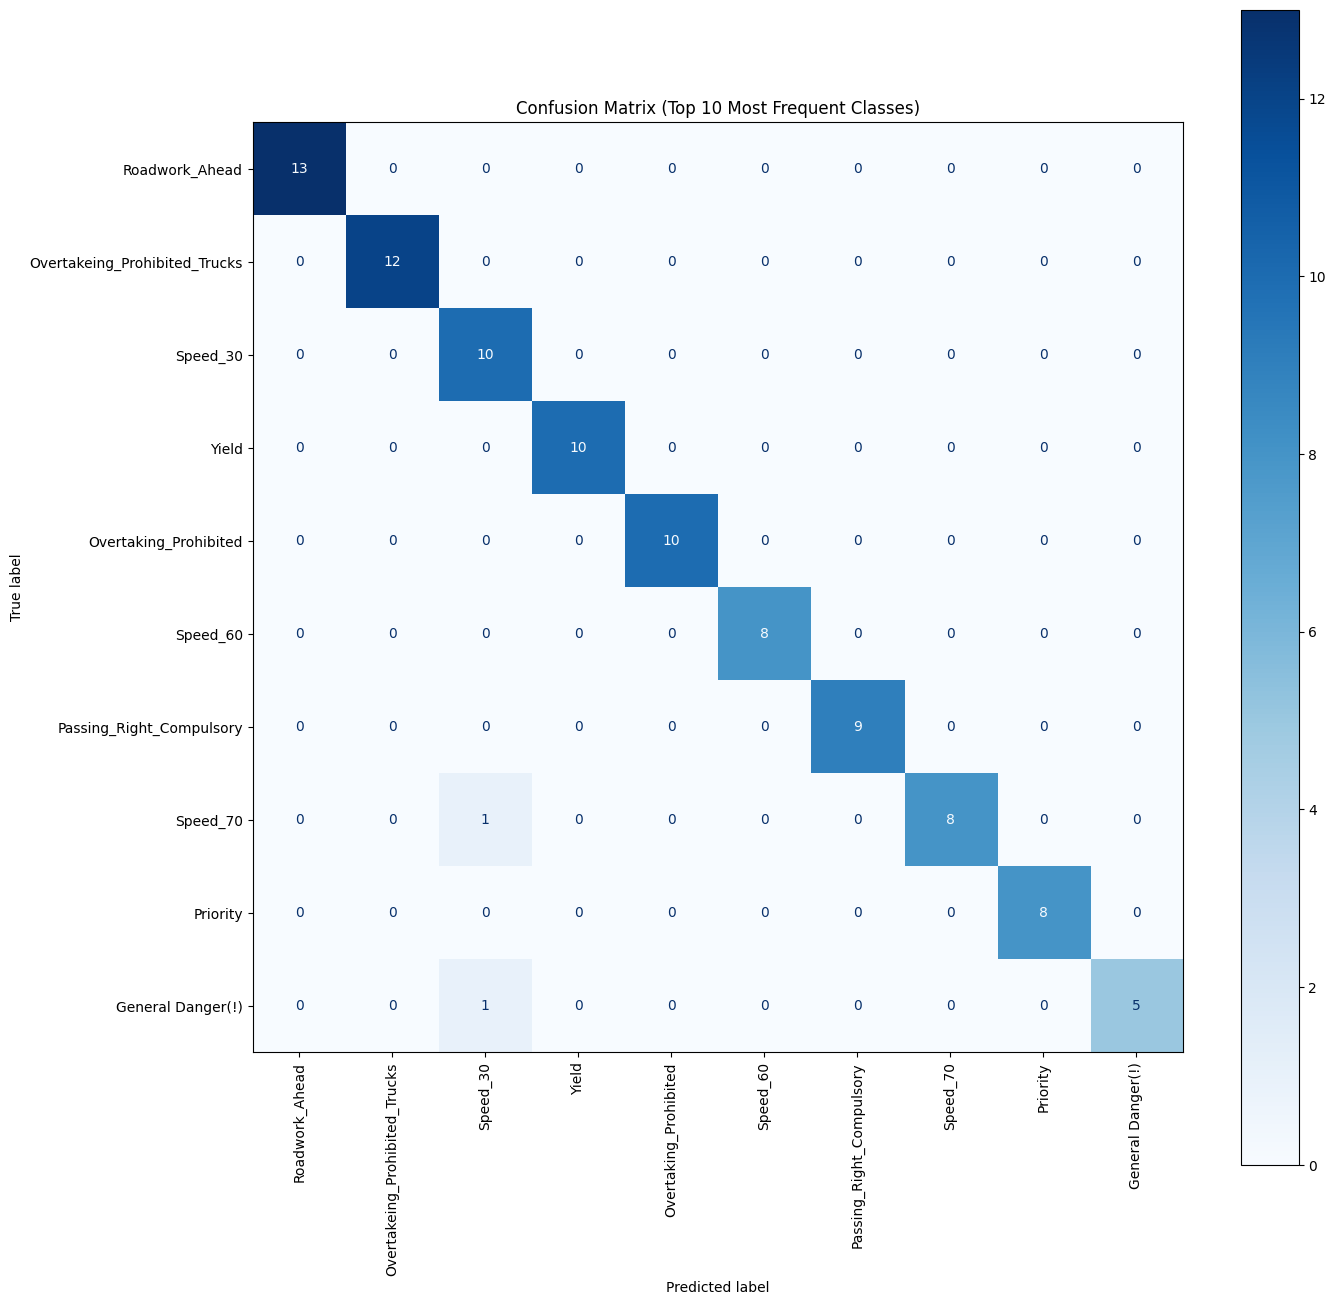

In [ ]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Identify the top 10 most frequent class IDs from true_labels
top_10_class_ids = pd.Series(true_labels).value_counts().nlargest(10).index.tolist()

# Filter true_labels and predictions to include only the top 10 classes
is_in_top_10 = np.isin(true_labels, top_10_class_ids)
top_10_true_labels = true_labels[is_in_top_10]
top_10_predictions = np.array(predictions)[is_in_top_10] # predictions is a list, convert to numpy array first

# Get the corresponding target names for the top 10 class IDs
top_10_filtered_target_names = [target_names[i] for i in top_10_class_ids]

# Calculate the confusion matrix for the top 10 classes
cm_top_10 = confusion_matrix(top_10_true_labels, top_10_predictions, labels=top_10_class_ids)

# Display the confusion matrix for the top 10 classes
fig_top_10, ax_top_10 = plt.subplots(figsize=(15,15)) # Adjust figsize for better readability if needed
plt.xticks(rotation = 90)
cmd_top_10 = ConfusionMatrixDisplay(cm_top_10, display_labels=top_10_filtered_target_names)
cmd_top_10.plot(ax=ax_top_10, cmap="Blues", values_format='.5g', xticks_rotation=90)
plt.title('Confusion Matrix (Top 10 Most Frequent Classes)')
plt.show()

In [ ]:
pip install lets-plot


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.4 MB/s eta 0:00:00


These next two graphs go together. They are looking at the accuracy and loss as you do more epochs to show that the model is learning. For accuracy, it shows it's not just memorizing the training data, but is able to correctly identify the traffic signs on data it hasn't seen. For loss, it reaches it's peak around 5 epochs.

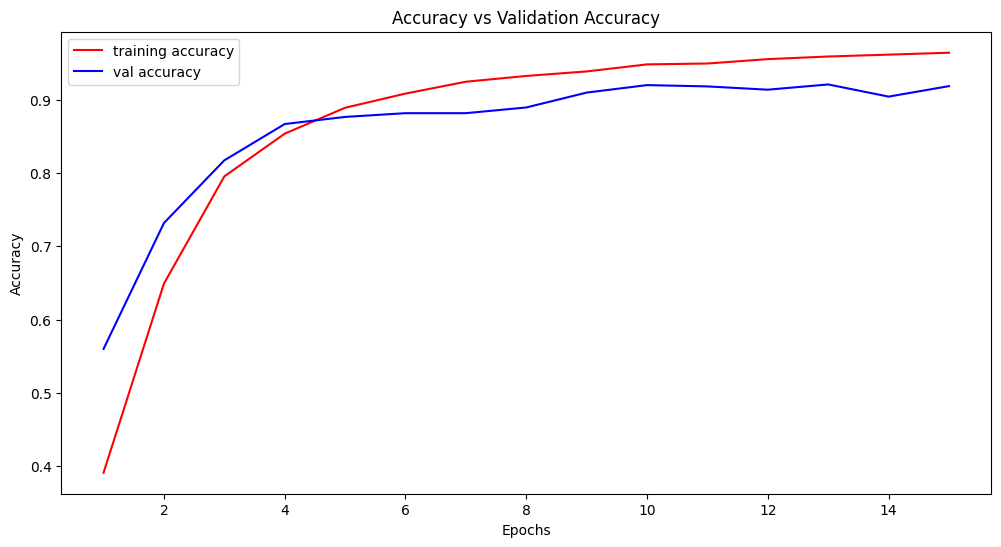

In [ ]:
import seaborn as sns

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


chart_data = {
    'epochs': list(range(1, len(accuracy) + 1)),
    'train_acc': accuracy,
    'val_acc': val_accuracy,
    'loss' : loss,
    'val_loss': val_loss
}

plt.figure(figsize=(12, 6))
sns.lineplot(data=chart_data, x='epochs', y='train_acc', color='red', label='training accuracy')
sns.lineplot(data=chart_data, x='epochs', y='val_acc', color='blue', label='val accuracy')
plt.title('Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(False)
plt.show()

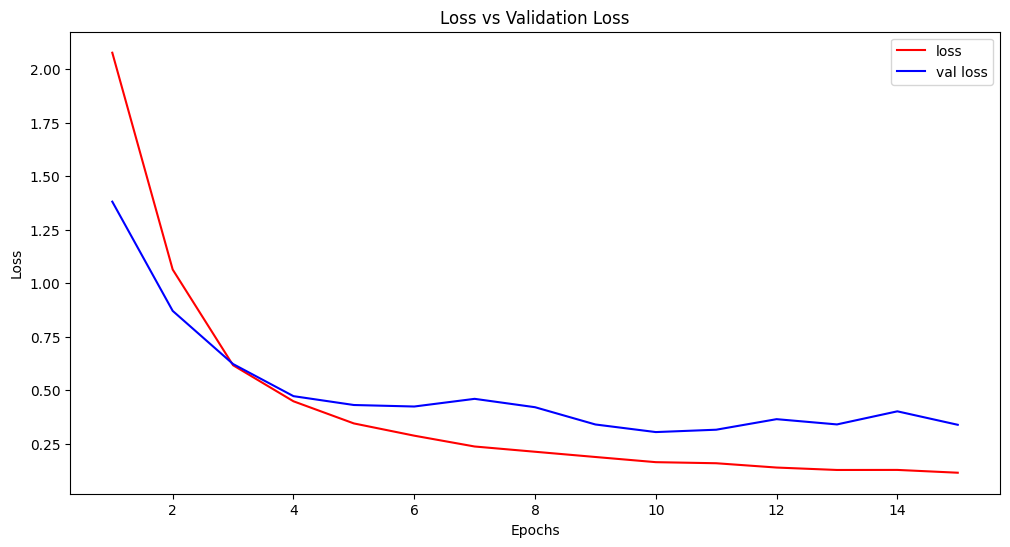

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=chart_data, x='epochs', y='loss', color='red', label='loss')
sns.lineplot(data=chart_data, x='epochs', y='val_loss', color='blue', label='val loss')
plt.title('Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)
plt.show()

/tmp/ipykernel_22391/4107825761.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


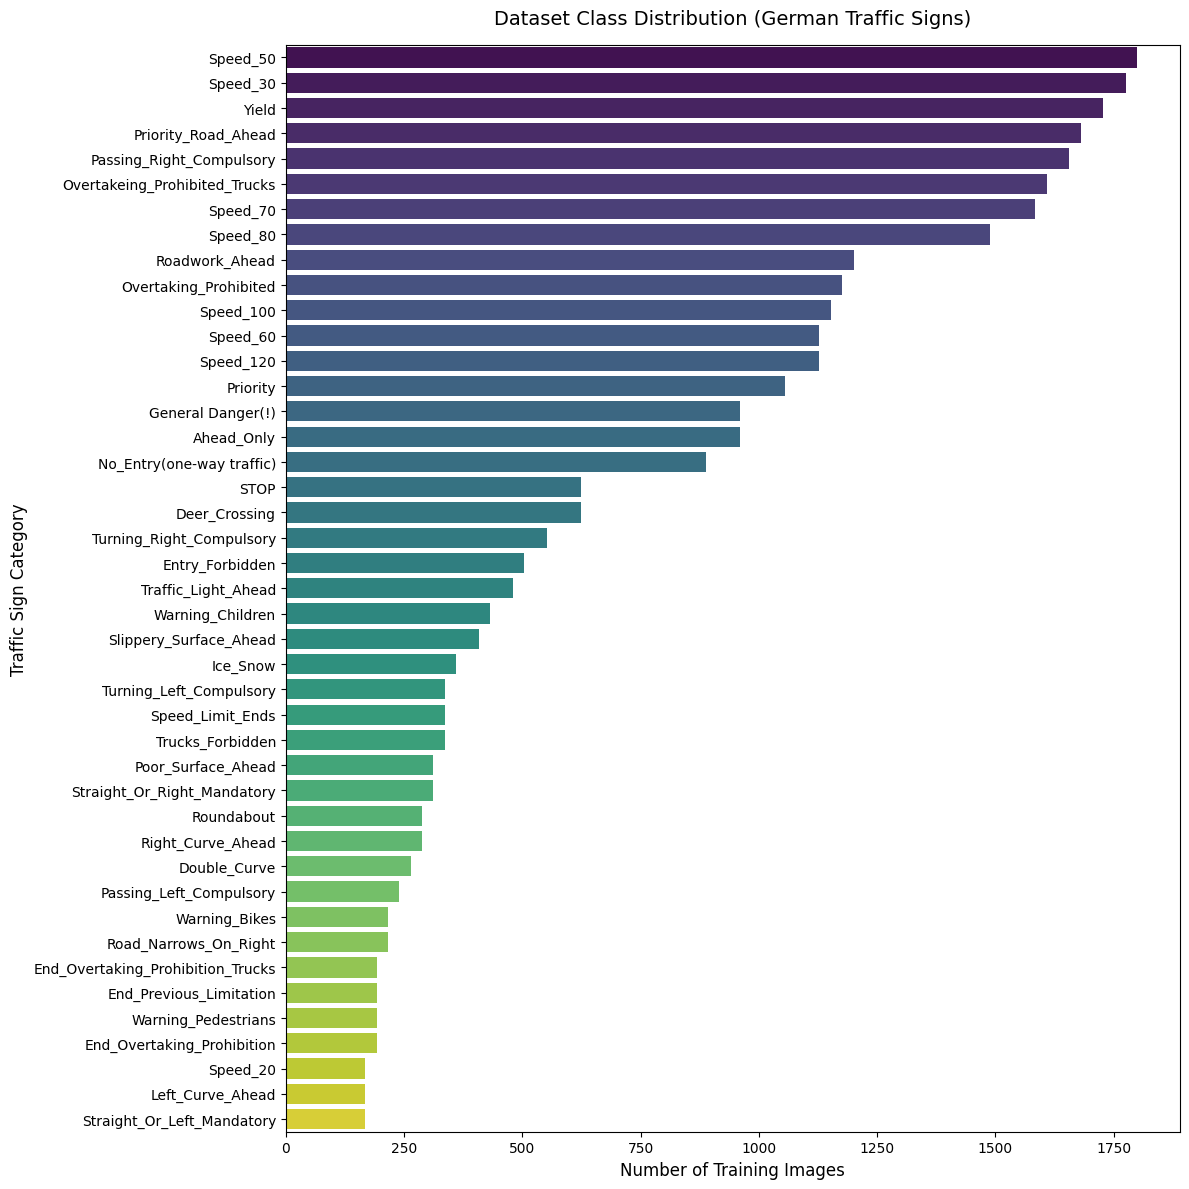

In [ ]:
# This graph shows how many counts of images there are. This helps us because it helps us understand why our model is identifying road signs correctly or incorrectly

# 1. Get the value counts of the classes as a DataFrame
counts_df = pd.Series(train_generator.classes).value_counts().reset_index()
counts_df.columns = ['class_id', 'count']

# 2. Use your existing target_names list!
# Because class_id matches the list index perfectly, we can look up the name directly.
counts_df['class_name'] = counts_df['class_id'].apply(lambda x: target_names[x])

# 3. Sort by count so it looks clean for the summary
counts_df = counts_df.sort_values(by='count', ascending=False)

# 4. Plot the horizontal bar chart
plt.figure(figsize=(12, 12))
sns.barplot(
    data=counts_df,
    x='count',
    y='class_name',
    palette='viridis'
)

plt.title('Dataset Class Distribution (German Traffic Signs)', fontsize=14, pad=15)
plt.xlabel('Number of Training Images', fontsize=12)
plt.ylabel('Traffic Sign Category', fontsize=12)
plt.tight_layout()
plt.show()

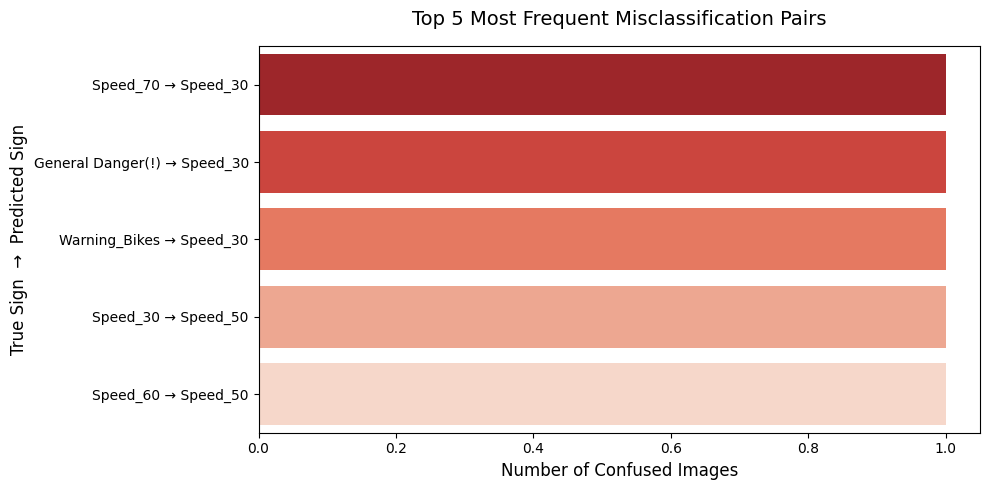

In [ ]:
# This shows us what our model is misclassifying.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calculate the raw confusion matrix for ALL 43 classes
# Use your original full true labels and predictions arrays here
raw_cm = confusion_matrix(true_labels, predictions)

# 2. Turn the 2D array into a labeled Pandas DataFrame
# Use filtered_target_names which matches the actual classes present in true_labels
cm_df = pd.DataFrame(raw_cm, index=filtered_target_names, columns=filtered_target_names)

# 3. Wipe out the main diagonal (set correct predictions to 0)
# This ensures we are ONLY looking at errors
np.fill_diagonal(cm_df.values, 0)

# 4. Flatten the matrix grid into a single column list
error_series = cm_df.unstack()
error_df = error_series.reset_index()
error_df.columns = ['Predicted_Sign', 'True_Sign', 'Error_Count']

# 5. Filter out pairs that had 0 errors and sort by the highest error counts
error_df = error_df[error_df['Error_Count'] > 0]
error_df = error_df.sort_values(by='Error_Count', ascending=False)

# 6. Isolate the top 5 worst offenders
top_5_errors = error_df.head(5).copy()

# 7. Create a clean, combined text label for the Y-axis
top_5_errors['Error_Pair'] = top_5_errors['True_Sign'] + ' → ' + top_5_errors['Predicted_Sign']

# 8. Plot the isolated errors
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_5_errors,
    x='Error_Count',
    y='Error_Pair',
    hue='Error_Pair', # Assign 'Error_Pair' to hue to suppress the FutureWarning
    palette='Reds_r',
    legend=False # Set legend=False since the y-axis labels already explain the colors
)

# 9. Format titles and labels for your summary
plt.title('Top 5 Most Frequent Misclassification Pairs', fontsize=14, pad=15)
plt.xlabel('Number of Confused Images', fontsize=12)
plt.ylabel('True Sign  →  Predicted Sign', fontsize=12)

plt.tight_layout()
plt.show()

## Testing the model
Once you have built and trained your model, the next step is to run the mini holdout images through it and see how well your model does at making predictions for images it has never seen before.

Since loading these images and formatting them for the model can be tricky, you may find the following code useful. This code only uses your model to predict the class label for a given image. You'll still need to compare those predictions to the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Previously, you were given a file that would check your results. This time you're given the answers to the first mini holdout dataset. You'll need to compare those predictions against the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Make sure to use the insights gained from the mini hold out dataset in your executive summary.


```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```



##Mini Hold out Dataset


Once you feel confident, you will need to predict for the full holdout dataset using the following code, and submit your csv file:

```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```

Data set de alan


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

Found 12630 images belonging to 1 classes.
395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step


In [ ]:
import pandas as pd

# This saves ONLY the raw prediction numbers (no column title, no row numbers)
pd.DataFrame(predictions).to_csv('holdout_predictions.csv', index=False, header=False)

print("Success! Created a file with only raw numbers.")

Success! Created a file with only raw numbers.
